# 06 — Interpretação dos Clusters (K-Means, K=5)

Este notebook analisa e interpreta os 5 clusters gerados pelo notebook `05-Kmeans.ipynb`,
cruzando os perfis de qualidade de telecomunicações (RQUAL) com os dados socioeconômicos e geográficos do IBGE.

**Entrada:** `rqual_2022_clusterizado.parquet`  
**Saída:** tabelas, gráficos e narrativa interpretativa por cluster

---

## Resumo dos clusters encontrados

| Cluster | N municípios | Perfil resumido |
|---------|-------------|------------------|
| **0** | 216 | Urbano-avançado: alta banda, alto PIB per capita, IDHM elevado (Sul/Sudeste) |
| **1** | 3.054 | Intermediário: desempenho médio em todos os indicadores (Sul/Sudeste) |
| **2** | 2.057 | Nordeste periférico: baixa resolução de problemas, maior população rural |
| **3** | 216 | Norte/Amazônico: pior atendimento e solução, municípios extensos e remotos |
| **4** | 27 | Capitais/destaques: um por UF, densidade e upload excepcionais |

In [1]:
# Bloco 0 — Setup e carregamento
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path
from IPython.display import display

# Carregar base clusterizada
ARQ = Path('rqual_2022_clusterizado.parquet')
df = pd.read_parquet(ARQ)

print(f'Shape: {df.shape}')
print(f'Clusters K-Means: {sorted(df["kmeans_cluster"].unique())}')
print(f'Distribuição:')
display(df['kmeans_cluster'].value_counts().sort_index().rename('n_municípios'))

Shape: (5570, 26)
Clusters K-Means: [0, 1, 2, 3, 4]
Distribuição:


kmeans_cluster
0     216
1    3054
2    2057
3     216
4      27
Name: n_municípios, dtype: int64

In [2]:
# Bloco 1 — Padronizar nomes de colunas para análise

# Indicadores RQUAL
IND_COLS = [c for c in ['IND2','IND4','IND5','IND8','IND9','INF1','INF4-UP'] if c in df.columns]

# Renomear colunas socioeconômicas para nomes curtos
rename_map = {}
for col in df.columns:
    if 'Agropecuária' in col or 'Agropecuaria' in col:
        rename_map[col] = 'pib_agropecuaria'
    elif 'Indústria' in col or 'Industria' in col:
        rename_map[col] = 'pib_industria'
    elif 'per capita' in col.lower() or 'Per capita' in col:
        rename_map[col] = 'pib_per_capita'
    elif 'Área' in col or 'Area' in col:
        rename_map[col] = 'area_km2'
    elif 'Densidade' in col or 'densidade' in col:
        rename_map[col] = 'densidade'
    elif 'Rural' in col and 'URB' in col:
        rename_map[col] = 'pop_rural'
    elif 'IDHM' in col:
        rename_map[col] = 'idhm'
    elif col.startswith('LAT__lat'):
        rename_map[col] = 'lat'
    elif col.startswith('LAT__lon'):
        rename_map[col] = 'lon'

df = df.rename(columns=rename_map)

SOC_COLS = [c for c in ['pib_agropecuaria','pib_industria','pib_per_capita',
                         'area_km2','densidade','pop_rural','idhm'] if c in df.columns]

print('Indicadores RQUAL:', IND_COLS)
print('Socioeconômicas:', SOC_COLS)

Indicadores RQUAL: ['IND2', 'IND4', 'IND5', 'IND8', 'IND9', 'INF1', 'INF4-UP']
Socioeconômicas: ['pib_agropecuaria', 'pib_industria', 'pib_per_capita', 'area_km2', 'densidade', 'pop_rural', 'idhm']


## 1. Perfil médio por cluster (z-scores)

In [3]:
# Bloco 2 — Tabela de perfil médio (valores já em z-score do pipeline anterior)

CLUSTER_LABELS = {
    0: 'C0: Urbano-Avançado (216)',
    1: 'C1: Intermediário (3.054)',
    2: 'C2: Nordeste Periférico (2.057)',
    3: 'C3: Norte/Amazônico (216)',
    4: 'C4: Capitais/Destaques (27)',
}

todas_feats = IND_COLS + SOC_COLS
perfil = df.groupby('kmeans_cluster')[todas_feats].mean().round(3)
perfil.index = perfil.index.map(CLUSTER_LABELS)

print('Perfil médio por cluster (z-scores):')
display(perfil)

Perfil médio por cluster (z-scores):


,IND2,IND4,IND5,IND8,IND9,INF1,INF4-UP,pib_agropecuaria,pib_industria,pib_per_capita,area_km2,densidade,pop_rural,idhm
kmeans_cluster,,,,,,,,,,,,,,
C0: Urbano-Avançado (216),-0.512,-0.149,0.540,0.165,0.544,-0.531,1.242,-0.007,1.464,1.108,-0.150,1.400,0.019,1.264
C1: Intermediário (3.054),-0.045,0.185,0.285,0.129,0.010,-0.099,-0.037,0.042,-0.098,0.158,-0.135,-0.114,-0.344,0.593
C2: Nordeste Periférico (2.057),0.069,-0.055,-0.264,-0.078,-0.069,0.176,-0.096,-0.242,-0.142,-0.440,-0.108,-0.109,0.331,-0.938
C3: Norte/Amazônico (216),0.166,-1.702,-2.086,-0.652,-0.072,0.330,-0.310,0.789,-0.100,0.093,1.886,-0.189,1.124,-0.917
C4: Capitais/Destaques (27),-0.680,0.140,0.283,0.069,0.360,-0.569,1.380,0.380,1.990,0.149,0.277,2.063,0.906,1.629


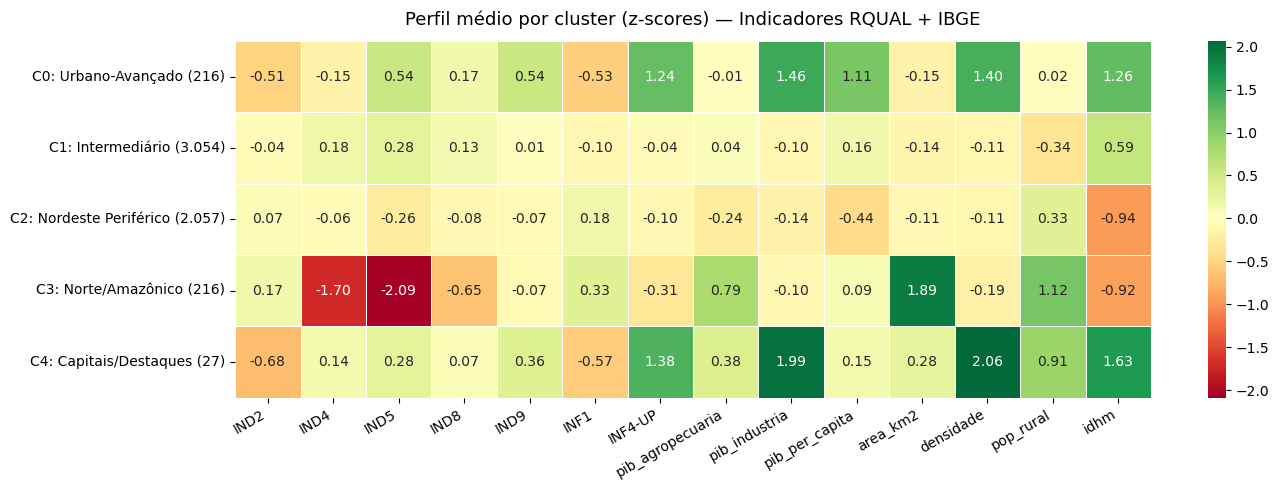

Salvo: fig_perfil_clusters_heatmap.png


In [4]:
# Bloco 3 — Heatmap de perfil dos clusters

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    perfil[todas_feats],
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Perfil médio por cluster (z-scores) — Indicadores RQUAL + IBGE', fontsize=13, pad=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('fig_perfil_clusters_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: fig_perfil_clusters_heatmap.png')

## 2. Distribuição geográfica por cluster

In [5]:
# Bloco 4 — Distribuição por UF e região

# Mapa região por UF
UF_REGIAO = {
    'AC':'Norte','AM':'Norte','AP':'Norte','PA':'Norte','RO':'Norte','RR':'Norte','TO':'Norte',
    'AL':'Nordeste','BA':'Nordeste','CE':'Nordeste','MA':'Nordeste','PB':'Nordeste',
    'PE':'Nordeste','PI':'Nordeste','RN':'Nordeste','SE':'Nordeste',
    'DF':'Centro-Oeste','GO':'Centro-Oeste','MS':'Centro-Oeste','MT':'Centro-Oeste',
    'ES':'Sudeste','MG':'Sudeste','RJ':'Sudeste','SP':'Sudeste',
    'PR':'Sul','RS':'Sul','SC':'Sul',
}

df['regiao'] = df['uf_rqual'].map(UF_REGIAO)

regiao_dist = (
    df.groupby(['kmeans_cluster','regiao'])
    .size()
    .unstack(fill_value=0)
    .assign(Total=lambda d: d.sum(axis=1))
)

# Percentual por cluster
regiao_pct = regiao_dist.div(regiao_dist['Total'], axis=0).drop(columns='Total').mul(100).round(1)
regiao_pct.index = regiao_pct.index.map(CLUSTER_LABELS)

print('Distribuição regional por cluster (%):')
display(regiao_pct)

Distribuição regional por cluster (%):


regiao,Centro-Oeste,Nordeste,Norte,Sudeste,Sul
kmeans_cluster,,,,,
C0: Urbano-Avançado (216),3.2,8.8,2.3,66.7,19.0
C1: Intermediário (3.054),13.6,0.2,1.1,47.5,37.5
C2: Nordeste Periférico (2.057),0.0,84.2,12.5,3.3,0.0
C3: Norte/Amazônico (216),18.1,13.0,68.1,0.9,0.0
C4: Capitais/Destaques (27),14.8,33.3,25.9,14.8,11.1


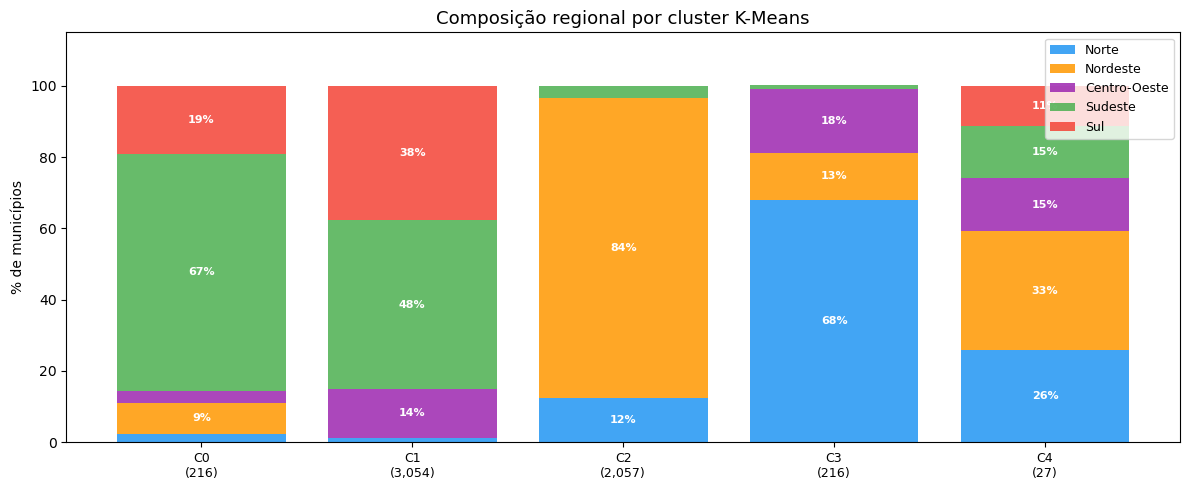

Salvo: fig_distribuicao_regional.png


In [6]:
# Bloco 5 — Gráfico de barras empilhadas por região

cores_regiao = {
    'Norte': '#2196F3',
    'Nordeste': '#FF9800',
    'Centro-Oeste': '#9C27B0',
    'Sudeste': '#4CAF50',
    'Sul': '#F44336',
}

fig, ax = plt.subplots(figsize=(12, 5))

bottom = np.zeros(len(regiao_pct))
for regiao in ['Norte','Nordeste','Centro-Oeste','Sudeste','Sul']:
    if regiao in regiao_pct.columns:
        vals = regiao_pct[regiao].values
        bars = ax.bar(range(len(regiao_pct)), vals, bottom=bottom,
                      label=regiao, color=cores_regiao[regiao], alpha=0.85)
        # rótulo dentro da barra se > 8%
        for j, (v, b) in enumerate(zip(vals, bottom)):
            if v > 8:
                ax.text(j, b + v/2, f'{v:.0f}%', ha='center', va='center',
                        fontsize=8, color='white', fontweight='bold')
        bottom += vals

ax.set_xticks(range(len(regiao_pct)))
ax.set_xticklabels(
    [f'C{i}\n({list(df.groupby("kmeans_cluster").size().sort_index())[i]:,})'
     for i in range(len(regiao_pct))],
    fontsize=9
)
ax.set_ylabel('% de municípios')
ax.set_title('Composição regional por cluster K-Means', fontsize=13)
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0, 115)
plt.tight_layout()
plt.savefig('fig_distribuicao_regional.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: fig_distribuicao_regional.png')

## 3. Radar chart — comparação dos clusters nos indicadores RQUAL

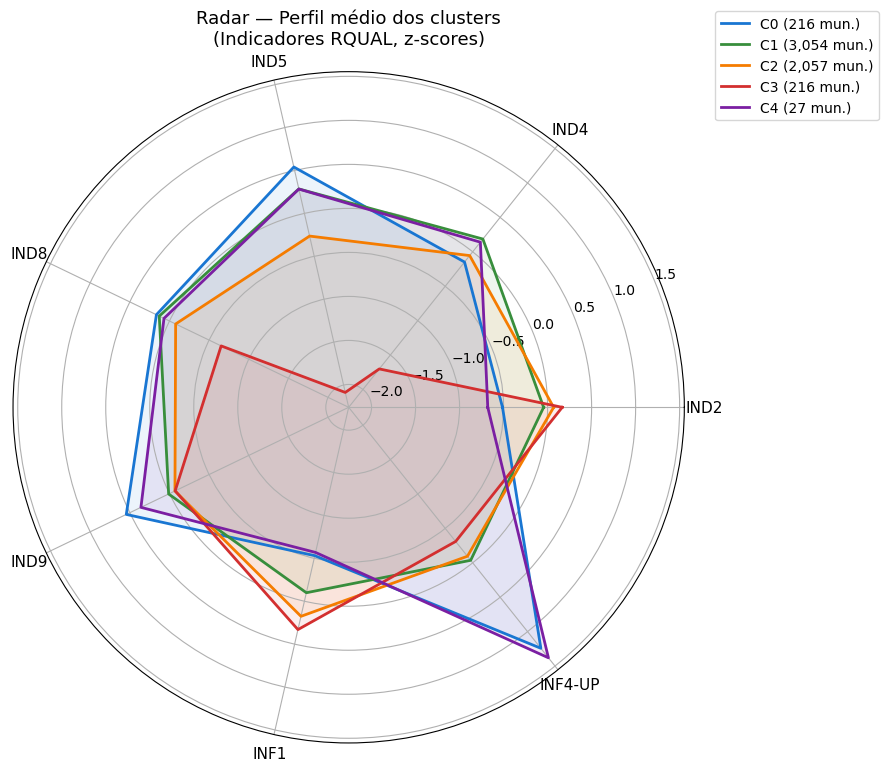

Salvo: fig_radar_clusters.png


In [7]:
# Bloco 6 — Radar chart

from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

categorias = IND_COLS
N = len(categorias)
angulos = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angulos += angulos[:1]  # fechar o radar

CORES = ['#1976D2','#388E3C','#F57C00','#D32F2F','#7B1FA2']

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for cluster_id, cor in enumerate(CORES):
    sub = df[df['kmeans_cluster'] == cluster_id]
    valores = sub[categorias].mean().tolist()
    valores += valores[:1]
    label = f'C{cluster_id} ({len(sub):,} mun.)'
    ax.plot(angulos, valores, color=cor, linewidth=2, label=label)
    ax.fill(angulos, valores, color=cor, alpha=0.08)

ax.set_xticks(angulos[:-1])
ax.set_xticklabels(categorias, fontsize=11)
ax.set_title('Radar — Perfil médio dos clusters\n(Indicadores RQUAL, z-scores)', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
plt.tight_layout()
plt.savefig('fig_radar_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: fig_radar_clusters.png')

## 4. Mapa geográfico dos clusters

Municípios sem coordenadas: 0


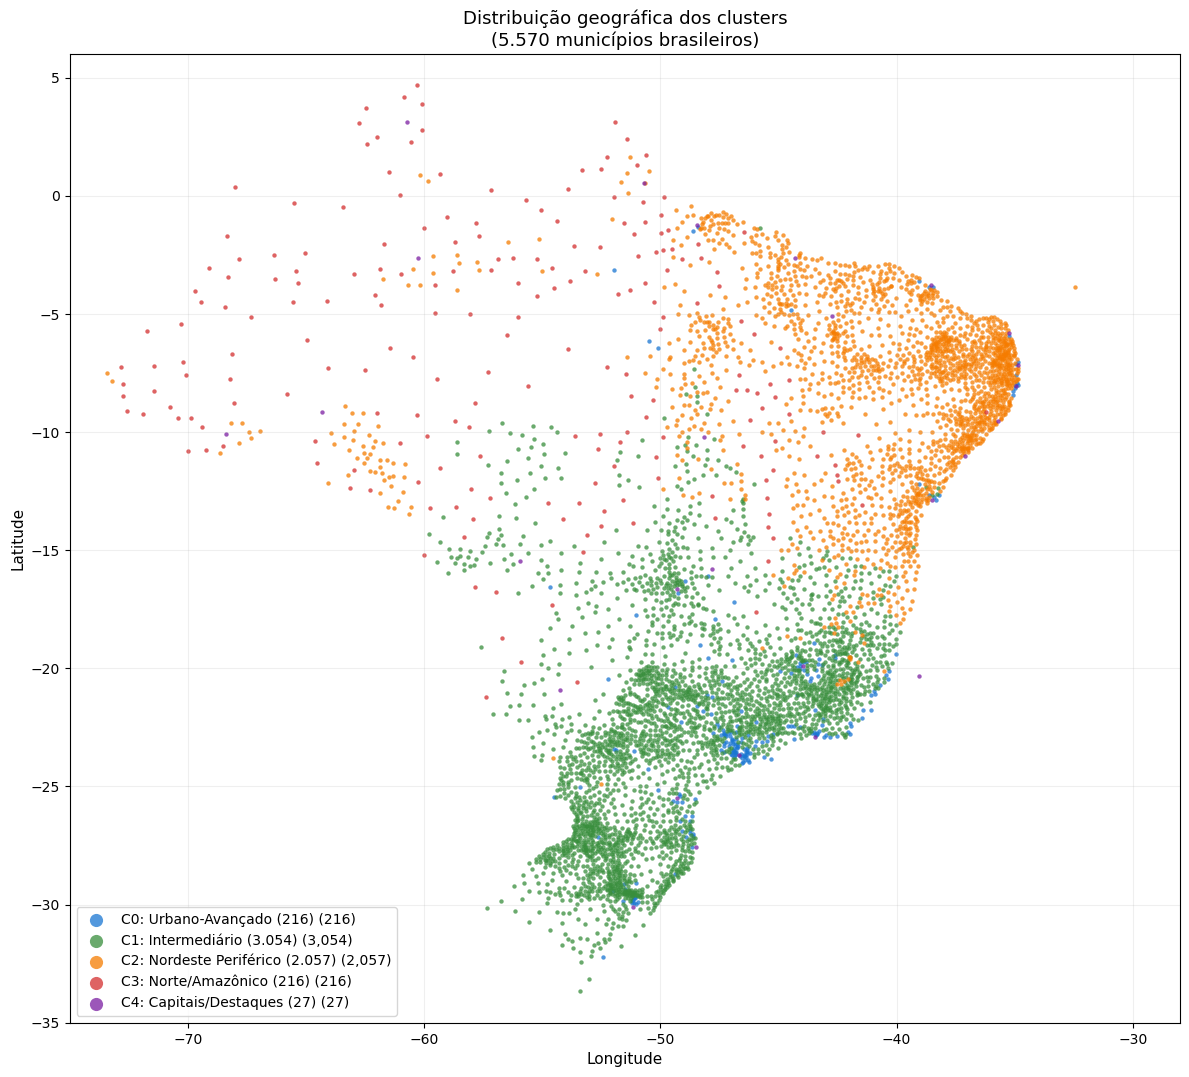

Salvo: fig_mapa_clusters.png


In [8]:
# Bloco 7 — Mapa geográfico dos clusters (coordenadas reais via geobr)

import warnings
warnings.filterwarnings('ignore')

from geobr import read_municipality
import geopandas as gpd

# Obter centroides oficiais de todos os 5.570 municípios
gdf = read_municipality(code_muni='all', year=2020)
gdf = gdf[['code_muni', 'geometry']].copy()

# Reprojetar para CRS projetado antes de calcular centroide (evita distorção)
gdf_proj = gdf.to_crs('EPSG:5880')  # SIRGAS 2000 / Brazil Polyconic
gdf['lat'] = gdf_proj.geometry.centroid.to_crs('EPSG:4326').y
gdf['lon'] = gdf_proj.geometry.centroid.to_crs('EPSG:4326').x
gdf = gdf.rename(columns={'code_muni': 'cod_mun'}).drop(columns='geometry')
gdf['cod_mun'] = gdf['cod_mun'].astype(int)

# Join com base clusterizada
df_map = df[['cod_mun', 'kmeans_cluster']].merge(gdf, on='cod_mun', how='left')
n_sem_coord = df_map[['lat','lon']].isna().any(axis=1).sum()
print(f'Municípios sem coordenadas: {n_sem_coord}')

fig, ax = plt.subplots(figsize=(12, 14))

for cluster_id, cor in enumerate(CORES):
    sub = df_map[df_map['kmeans_cluster'] == cluster_id].dropna(subset=['lat','lon'])
    nome = CLUSTER_LABELS[cluster_id].split(':')[1].strip()
    ax.scatter(
        sub['lon'], sub['lat'],
        c=cor, s=10, alpha=0.75, linewidths=0,
        label=f'C{cluster_id}: {nome} ({len(sub):,})'
    )

ax.set_xlabel('Longitude', fontsize=11)
ax.set_ylabel('Latitude', fontsize=11)
ax.set_title('Distribuição geográfica dos clusters\n(5.570 municípios brasileiros)', fontsize=13)
ax.legend(fontsize=10, markerscale=3, loc='lower left')
ax.set_xlim(-75, -28)
ax.set_ylim(-35, 6)
ax.set_aspect('equal')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('fig_mapa_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: fig_mapa_clusters.png')

## 5. Análise interpretativa narrativa

### Cluster 0 — Urbano-Avançado (216 municípios)

**Localização:** Concentrado no Sul e Sudeste — São Paulo (81), Minas Gerais (30), Rio de Janeiro (25), Rio Grande do Sul (15), Paraná (13), Santa Catarina (13).

**Perfil de qualidade:**
- `INF4-UP` elevado (+1.24σ): throughput de upload acima da média — serviços de banda larga de maior capacidade
- `IND5` positivo (+0.54σ): alta taxa de resolução de problemas no prazo
- `IND2` negativo (−0.51σ): menos reclamações — usuários mais satisfeitos
- `INF1` negativo (−0.53σ): menor cobertura bruta, mas alta qualidade onde existe

**Perfil socioeconômico:**
- PIB per capita (+1.11σ) e IDHM (+1.26σ) muito acima da média
- Densidade demográfica elevada (+1.40σ)
- Municípios tipicamente metropolitanos ou de grande porte

**Interpretação:** Municípios com maior desenvolvimento socioeconômico e melhor infraestrutura de telecom. A qualidade do serviço acompanha o nível de renda e urbanização.

---

### Cluster 1 — Intermediário (3.054 municípios — 54,8% do total)

**Localização:** Majoritariamente Sul e Sudeste — São Paulo (563), Minas Gerais (754), Rio Grande do Sul (481), Paraná (384), Santa Catarina (281), Goiás (239).

**Perfil de qualidade:**
- Todos os indicadores próximos de zero — desempenho médio nacional
- `IND4` levemente positivo (+0.19σ): atendimento acima da média

**Perfil socioeconômico:**
- PIB per capita (+0.16σ) e IDHM (+0.59σ) acima da média
- Perfil de municípios de médio porte com serviços consolidados

**Interpretação:** Cluster da "maioria silenciosa" — municípios com serviços adequados, sem problemas críticos. Representa o padrão de referência para políticas públicas de manutenção de qualidade.

---

### Cluster 2 — Nordeste Periférico (2.057 municípios — 36,9%)

**Localização:** Nordeste quase exclusivo — Bahia (391), Piauí (217), Paraíba (220), Ceará (180), Pernambuco (177), Maranhão (207), Alagoas (100), Rio Grande do Norte (165), Sergipe (74). Também inclui Pará (86) e Tocantins (98).

**Perfil de qualidade:**
- `IND5` negativo (−0.26σ): baixa taxa de resolução de problemas no prazo — operadoras demoram mais para resolver reclamações
- `IND4` negativo (−0.06σ): ligeiramente menor taxa de atendimento
- `INF1` positivo (+0.18σ): maior cobertura/infraestrutura (paradoxalmente)

**Perfil socioeconômico:**
- PIB per capita (−0.44σ) e IDHM (−0.94σ) bem abaixo da média
- Alta proporção de população rural (+0.33σ)

**Interpretação:** Municípios com infraestrutura expandida (cobertura existe), mas com problemas de **qualidade operacional** — a rede chega, mas o atendimento ao cliente é mais lento. Reflete desafio típico de expansão sem maturidade operacional.

---

### Cluster 3 — Norte/Amazônico (216 municípios)

**Localização:** Amazônia e Norte — Pará (52), Amazonas (50), Mato Grosso (34), Acre (12), Roraima (12), Rondônia (7), Amapá (8), Tocantins (6), Maranhão (7), Bahia (14).

**Perfil de qualidade:**
- `IND5` muito negativo (−2.09σ): **pior resolução de problemas no prazo de todo o Brasil**
- `IND4` muito negativo (−1.70σ): taxa de atendimento crítica
- `IND8` negativo (−0.65σ): menor disponibilidade do serviço

**Perfil socioeconômico:**
- Área territorial muito elevada (+1.89σ) — municípios imensamente extensos
- Alta proporção de população rural (+1.12σ)
- IDHM baixo (−0.92σ)
- Alto VAB agropecuário (+0.79σ) — economia baseada no setor primário

**Interpretação:** Municípios de **alta vulnerabilidade** de telecomunicações. A combinação de área geográfica extensa, baixa densidade e economia primária cria barreiras severas à qualidade de serviço. Prioridade máxima para políticas de expansão e qualidade regulatória.

---

### Cluster 4 — Capitais/Destaques (27 municípios)

**Localização:** Exatamente 1 município por UF (26 UFs + DF = 27) — provavelmente as capitais estaduais.

**Perfil de qualidade:**
- `INF4-UP` muito elevado (+1.38σ): maior throughput de upload do Brasil
- `IND2` negativo (−0.68σ): pouquíssimas reclamações
- `INF1` negativo (−0.57σ): menor cobertura bruta (faz sentido: capitais têm menos município mas altíssima qualidade pontual)

**Perfil socioeconômico:**
- PIB indústria (+1.99σ) e densidade (+2.06σ) excepcionalmente elevados
- IDHM (+1.63σ) mais alto de todos os clusters

**Interpretação:** Capitais ou municípios-polo com infraestrutura premium. Servem como **referência de benchmark** para o que é tecnicamente possível no país quando há investimento e densidade econômica suficientes.

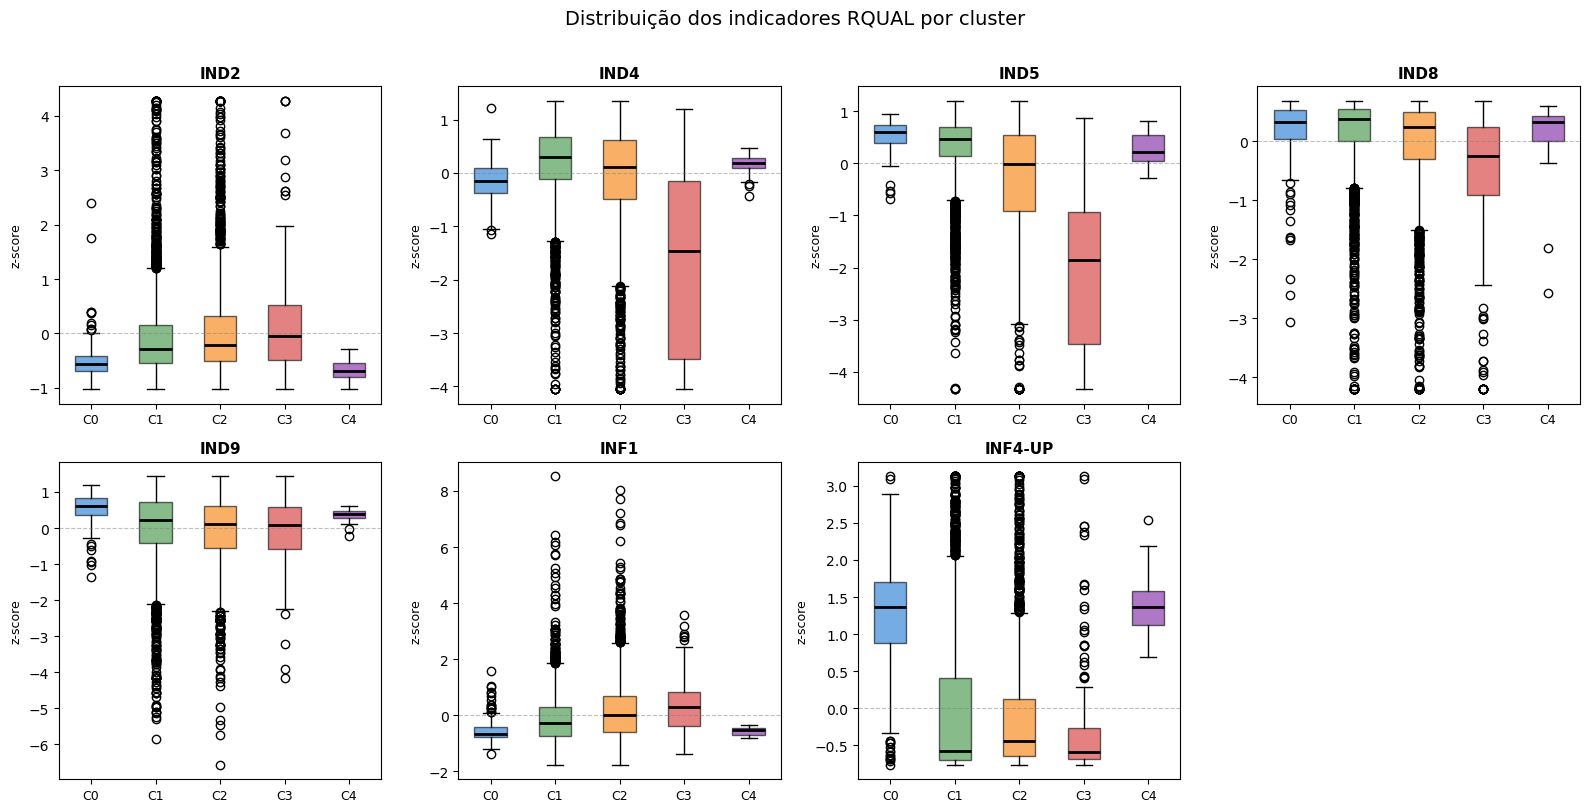

Salvo: fig_boxplot_indicadores.png


In [9]:
# Bloco 8 — Box plots comparativos dos indicadores RQUAL por cluster

n_ind = len(IND_COLS)
ncols = 4
nrows = (n_ind + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for i, ind in enumerate(IND_COLS):
    ax = axes[i]
    data_by_cluster = [
        df[df['kmeans_cluster'] == c][ind].dropna().values
        for c in sorted(df['kmeans_cluster'].unique())
    ]
    bp = ax.boxplot(data_by_cluster, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2))
    for patch, cor in zip(bp['boxes'], CORES):
        patch.set_facecolor(cor)
        patch.set_alpha(0.6)
    ax.set_title(ind, fontsize=11, fontweight='bold')
    ax.set_xticklabels([f'C{c}' for c in sorted(df['kmeans_cluster'].unique())], fontsize=9)
    ax.set_ylabel('z-score', fontsize=9)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

# Esconder eixos extras
for j in range(n_ind, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribuição dos indicadores RQUAL por cluster', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('fig_boxplot_indicadores.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: fig_boxplot_indicadores.png')

## 6. Implicações para políticas públicas

Com base na segmentação, identificamos **três eixos prioritários de atuação regulatória**:

### Eixo 1 — Expansão de Qualidade (Cluster 3 — Norte/Amazônico)
- **Problema:** Municípios remotos com pior desempenho em atendimento e resolução
- **Ação:** Metas diferenciadas de SLA para prestadoras operando em municípios de alta extensão territorial
- **Indicadores-alvo:** IND4 (atendimento) e IND5 (resolução no prazo)

### Eixo 2 — Maturidade Operacional (Cluster 2 — Nordeste)
- **Problema:** Infraestrutura existe, mas qualidade operacional é inferior
- **Ação:** Programas de capacitação e monitoramento de SLA nas prestadoras regionais
- **Indicadores-alvo:** IND5 (resolução) e IND2 (reclamações)

### Eixo 3 — Manutenção e Benchmark (Clusters 0 e 4)
- **Papel:** Estabelecer padrões de referência para o restante do país
- **Ação:** Publicar benchmarks das melhores práticas e criar incentivos para replicação
- **Indicadores-alvo:** INF4-UP, IND8 (disponibilidade)

In [10]:
# Bloco 9 — Exportar tabela resumo como CSV

resumo = df.groupby('kmeans_cluster').agg(
    n_municipios=('cod_mun', 'count'),
    **{ind: (ind, 'mean') for ind in IND_COLS},
    **{soc: (soc, 'mean') for soc in SOC_COLS},
).round(3)

NOMES_CLUSTERS = {
    0: 'Urbano-Avançado',
    1: 'Intermediário',
    2: 'Nordeste-Periférico',
    3: 'Norte-Amazônico',
    4: 'Capitais-Destaques',
}
resumo.index = resumo.index.map(NOMES_CLUSTERS)
resumo.index.name = 'cluster'

resumo.to_csv('tabela_resumo_clusters.csv')
print('Salvo: tabela_resumo_clusters.csv')
display(resumo)

Salvo: tabela_resumo_clusters.csv


,n_municipios,IND2,IND4,IND5,IND8,IND9,INF1,INF4-UP,pib_agropecuaria,pib_industria,pib_per_capita,area_km2,densidade,pop_rural,idhm
cluster,,,,,,,,,,,,,,,
Urbano-Avançado,216,-0.512,-0.149,0.540,0.165,0.544,-0.531,1.242,-0.007,1.464,1.108,-0.150,1.400,0.019,1.264
Intermediário,3054,-0.045,0.185,0.285,0.129,0.010,-0.099,-0.037,0.042,-0.098,0.158,-0.135,-0.114,-0.344,0.593
Nordeste-Periférico,2057,0.069,-0.055,-0.264,-0.078,-0.069,0.176,-0.096,-0.242,-0.142,-0.440,-0.108,-0.109,0.331,-0.938
Norte-Amazônico,216,0.166,-1.702,-2.086,-0.652,-0.072,0.330,-0.310,0.789,-0.100,0.093,1.886,-0.189,1.124,-0.917
Capitais-Destaques,27,-0.680,0.140,0.283,0.069,0.360,-0.569,1.380,0.380,1.990,0.149,0.277,2.063,0.906,1.629
